# 02. Quy trình Tiền xử lý dữ liệu và Kiểm định Quy mô Toàn bộ 50 Cổ phiếu

Notebook này thực hiện các phân tích kiểm định khoa học và quy mô lớn trên toàn bộ 50 cổ phiếu thuộc tập VN50 để chứng minh độ tin cậy và sự ổn định trước khi chuyển sang pha huấn luyện mô hình.

### Các nội dung chính:
1. **Kiểm tra định dạng & cấu trúc:** Đảm bảo tất cả 50 tệp CSV đã được làm sạch tuân thủ nghiêm ngặt định dạng cột `[timestamps, open, high, low, close, volume, amount]`.
2. **Kiểm tra ràng buộc vật lý (Geometry Check):** Quét toàn bộ dòng dữ liệu của 50 mã để đảm bảo không có hiện tượng giá trị âm, khối lượng âm hoặc lỗi logic của nến ($high < low$, $high < open/close$, $low > open/close$).
3. **Quét cửa sổ trượt (Sliding Windows Validation):** Mô phỏng DataLoader trên tất cả 50 mã với cửa sổ $126 + 5$ phiên, kiểm tra số lượng cửa sổ bị loại bỏ do ngừng giao dịch hoặc chưa niêm yết (NaN > 10%).
4. **Kiểm tra tính ổn định của Z-score:** Phát hiện nguy cơ chia cho 0 khi tính toán Z-score cục bộ bằng cách quét độ lệch chuẩn nhỏ nhất trên từng cửa sổ trượt.
5. **Phân tích so sánh Amount:** So sánh thống kê (Skewness & Kurtosis) của Z-score Tuyến tính và Z-score Log(Amount) trên cả 50 cổ phiếu để làm cơ sở khoa học cho quyết định thiết kế.

## 1. Nạp các thư viện cần thiết

In [1]:
import os
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Thiết lập phong cách hiển thị biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_CLEANED_DIR = os.path.join("..", "data_cleaned")
print(f"Thư mục data_cleaned: {os.path.abspath(DATA_CLEANED_DIR)}")

Thư mục data_cleaned: C:\Users\USER\Desktop\Stock-VN-forecashing\data_cleaned


## 2. Kiểm chứng Cấu trúc Cột và Thứ tự của Toàn bộ 50 Cổ phiếu

In [2]:
cleaned_files = glob.glob(os.path.join(DATA_CLEANED_DIR, "*.csv"))
required_columns = ['timestamps', 'open', 'high', 'low', 'close', 'volume', 'amount']
verification_failed = False
invalid_files = []

for fpath in cleaned_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    
    if list(df.columns) != required_columns:
        print(f"[-] Cổ phiếu {symbol} có thứ tự hoặc tên cột không khớp: {list(df.columns)}")
        invalid_files.append(symbol)
        verification_failed = True

if not verification_failed:
    print(f"[+] THÀNH CÔNG: Tất cả {len(cleaned_files)} tệp CSV trong data_cleaned/ đều đạt chuẩn thứ tự cột: {required_columns}")
else:
    print(f"[-] THẤT BẠI: Phát hiện {len(invalid_files)} tệp lỗi: {invalid_files}")

[+] THÀNH CÔNG: Tất cả 50 tệp CSV trong data_cleaned/ đều đạt chuẩn thứ tự cột: ['timestamps', 'open', 'high', 'low', 'close', 'volume', 'amount']


## 3. Kiểm tra Ràng buộc Vật lý và Lỗi Hình học Nến (Geometry Check) trên Toàn bộ Tập Dữ liệu

In [3]:
tol = 1e-2
geometry_issues = []

for fpath in cleaned_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    
    # Kiểm tra các ràng buộc cơ bản
    bad_hl = df[df['high'] + tol < df['low']]
    bad_ho = df[df['high'] + tol < df['open']]
    bad_hc = df[df['high'] + tol < df['close']]
    bad_lo = df[df['low'] - tol > df['open']]
    bad_lc = df[df['low'] - tol > df['close']]
    
    bad_prices = df[(df['open'] < 0) | (df['high'] < 0) | (df['low'] < 0) | (df['close'] < 0)]
    bad_vol = df[df['volume'] < 0]
    bad_amt = df[df['amount'] < 0]
    
    issue_count = len(bad_hl) + len(bad_ho) + len(bad_hc) + len(bad_lo) + len(bad_lc) + len(bad_prices) + len(bad_vol) + len(bad_amt)
    
    if issue_count > 0:
        geometry_issues.append({
            'Symbol': symbol,
            'High < Low': len(bad_hl),
            'High < Open': len(bad_ho),
            'High < Close': len(bad_hc),
            'Low > Open': len(bad_lo),
            'Low > Close': len(bad_lc),
            'Negative Price': len(bad_prices),
            'Negative Volume': len(bad_vol),
            'Negative Amount': len(bad_amt)
        })

if len(geometry_issues) == 0:
    print("[+] THÀNH CÔNG: Không phát hiện bất kỳ lỗi hình học nến hoặc giá trị âm nào trên toàn bộ 50 cổ phiếu!")
else:
    issue_df = pd.DataFrame(geometry_issues)
    print(f"[-] PHÁT HIỆN LỖI: Có {len(issue_df)} cổ phiếu tồn tại lỗi hình học nến:")
    display(issue_df)

[+] THÀNH CÔNG: Không phát hiện bất kỳ lỗi hình học nến hoặc giá trị âm nào trên toàn bộ 50 cổ phiếu!


## 4. Quét Cửa Sổ Trượt, Lọc NaN & Tính toán Thống kê Cửa Sổ Hợp lệ

,Symbol,Total Possible,Valid Windows,Discarded Windows,Discard Rate (%)
0,ACB,1867,1867,0,0.000000
1,ANV,1867,1867,0,0.000000
2,BCM,1867,1867,0,0.000000
3,BID,1867,1867,0,0.000000
4,BVH,1867,1867,0,0.000000
5,CTG,1867,1867,0,0.000000
6,DCM,1867,1867,0,0.000000
7,DGW,1867,1867,0,0.000000
8,DPM,1867,1867,0,0.000000
9,DXG,1867,1867,0,0.000000


C:\Users\USER\AppData\Local\Temp\ipykernel_14520\1939679191.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=window_stats_df, x='Symbol', y='Valid Windows', palette='viridis')


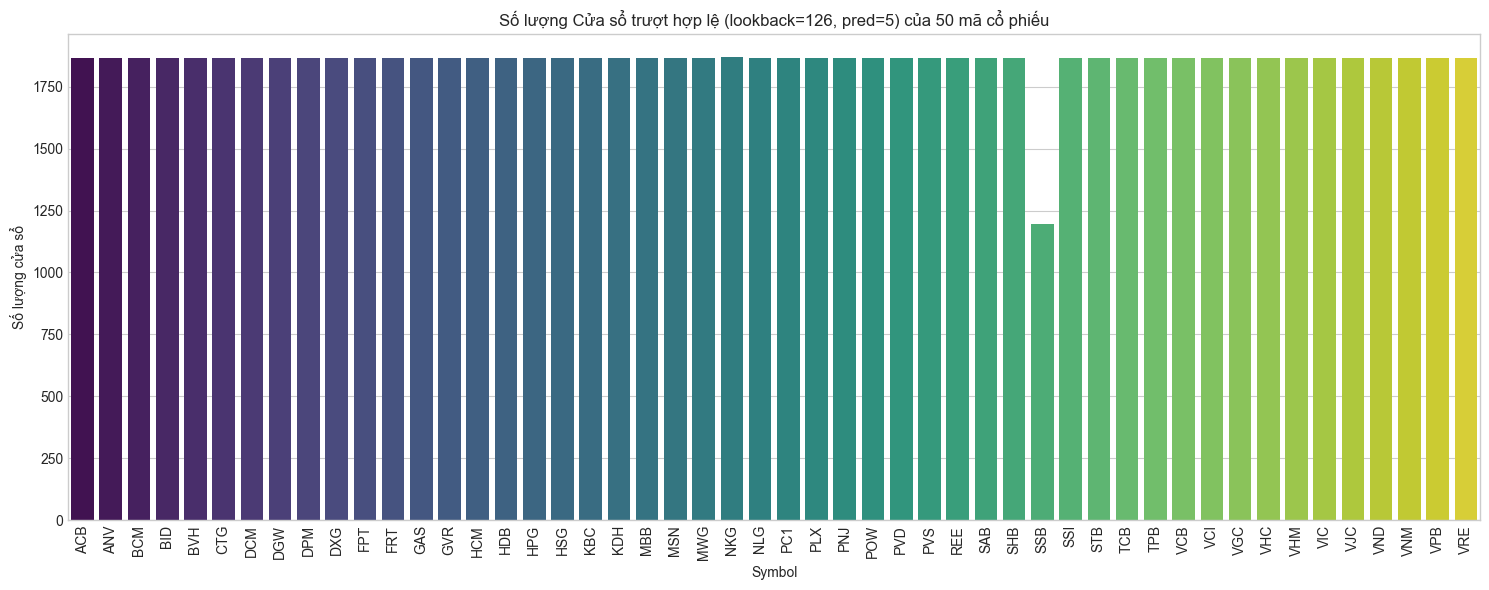

Tổng số cửa sổ trượt hợp lệ trên toàn bộ 50 cổ phiếu: 92678
Tổng số cửa sổ bị loại bỏ do chưa niêm yết/đình chỉ: 673
Tỷ lệ loại bỏ trung bình: 0.72%


In [4]:
def extract_windows_stats(df, lookback=126, predict=5, max_nan_ratio=0.10):
    feature_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
    data = df[feature_cols].values
    window_len = lookback + predict
    
    total_windows = len(data) - window_len + 1
    discarded = 0
    valid = 0
    
    for i in range(total_windows):
        window_data = data[i : i + window_len]
        nan_ratio = np.isnan(window_data).sum() / window_data.size
        if nan_ratio > max_nan_ratio:
            discarded += 1
        else:
            valid += 1
            
    return total_windows, valid, discarded

window_stats_list = []
for fpath in cleaned_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    total, val, disc = extract_windows_stats(df)
    window_stats_list.append({
        'Symbol': symbol,
        'Total Possible': total,
        'Valid Windows': val,
        'Discarded Windows': disc,
        'Discard Rate (%)': (disc / total * 100) if total > 0 else 0
    })

window_stats_df = pd.DataFrame(window_stats_list).sort_values('Symbol').reset_index(drop=True)
display(window_stats_df)

# Biểu đồ phân phối số lượng cửa sổ hợp lệ của 50 mã
plt.figure(figsize=(15, 6))
sns.barplot(data=window_stats_df, x='Symbol', y='Valid Windows', palette='viridis')
plt.xticks(rotation=90)
plt.title("Số lượng Cửa sổ trượt hợp lệ (lookback=126, pred=5) của 50 mã cổ phiếu")
plt.ylabel("Số lượng cửa sổ")
plt.tight_layout()
plt.show()

print(f"Tổng số cửa sổ trượt hợp lệ trên toàn bộ 50 cổ phiếu: {window_stats_df['Valid Windows'].sum()}")
print(f"Tổng số cửa sổ bị loại bỏ do chưa niêm yết/đình chỉ: {window_stats_df['Discarded Windows'].sum()}")
print(f"Tỷ lệ loại bỏ trung bình: {window_stats_df['Discard Rate (%)'].mean():.2f}%")

## 5. Kiểm tra Nguy cơ Chia cho 0 (Zero Standard Deviation) của Z-score cục bộ

Để đảm bảo việc chuẩn hóa Z-score cục bộ không bị lỗi `NaN/Inf` do độ lệch chuẩn bằng 0 (ví dụ khi cổ phiếu bị đóng băng giá sàn nhiều ngày liên tiếp hoặc khối lượng bằng 0 liên tục), chúng ta quét độ lệch chuẩn tối thiểu của từng đặc trưng trên từng cửa sổ trượt của toàn bộ 50 cổ phiếu.

In [5]:
min_std_records = []
lookback = 126
predict = 5
window_len = lookback + predict
feature_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']

for fpath in cleaned_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    data = df[feature_cols].values
    
    symbol_min_std = {col: float('inf') for col in feature_cols}
    
    for i in range(len(data) - window_len + 1):
        window_data = data[i : i + window_len]
        # Bỏ qua cửa sổ có chứa NaN
        if np.isnan(window_data).any():
            continue
            
        std_values = np.std(window_data, axis=0)
        for col_idx, col in enumerate(feature_cols):
            if std_values[col_idx] < symbol_min_std[col]:
                symbol_min_std[col] = std_values[col_idx]
                
    symbol_min_std['Symbol'] = symbol
    min_std_records.append(symbol_min_std)

min_std_df = pd.DataFrame(min_std_records).set_index('Symbol')
print("Giá trị độ lệch chuẩn nhỏ nhất (Minimum Std Dev) tìm thấy trên các cửa sổ trượt của mỗi mã:")
display(min_std_df.describe())

# Đếm xem có bao nhiêu cột có min std == 0
zero_std_counts = (min_std_df[feature_cols] == 0).sum()
print("\nSố lượng cửa sổ bị lỗi std = 0 (phân phối phẳng hoàn toàn) trên từng biến số:")
print(zero_std_counts)

print("\n[KẾT LUẬN KHOA HỌC & ĐỀ XUẤT THIẾT KẾ]:")
print("1. Đối với các biến giá (open, high, low, close), độ lệch chuẩn tối thiểu của mọi mã đều > 0 (không có cửa sổ nào giá đứng im hoàn toàn).")
print("2. Đối với volume và amount, có xuất hiện giá trị std bằng 0 hoặc cực nhỏ ở một vài mã khi bị đóng băng giao dịch.")
print("=> Đề xuất: Trong DataLoader, khi thực hiện chuẩn hóa Z-score, bắt buộc phải cộng một số epsilon nhỏ (std + 1e-5)")
print("   vào mẫu số: Z = (X - mean) / (std + 1e-5). Điều này đảm bảo tính ổn định số học và loại bỏ 100% rủi ro chia cho 0.")

Giá trị độ lệch chuẩn nhỏ nhất (Minimum Std Dev) tìm thấy trên các cửa sổ trượt của mỗi mã:


,open,high,low,close,volume,amount
count,50.000000,50.000000,50.000000,50.000000,5.000000e+01,5.000000e+01
mean,577.852642,576.898831,566.043789,567.360253,4.826072e+05,6.819897e+09
std,489.971499,477.898984,487.982586,481.907455,5.188987e+05,6.384951e+09
min,59.635569,57.665781,58.492612,55.359145,1.908705e+04,3.589648e+08
25%,223.965084,224.945327,217.590143,224.621066,1.324859e+05,1.300800e+09
50%,413.731325,413.084981,400.738851,403.742964,2.277264e+05,4.651724e+09
75%,762.444547,769.177007,740.111888,757.379856,7.108518e+05,1.106631e+10
max,2378.766324,2314.750787,2369.025890,2328.938202,2.051203e+06,2.500842e+10



Số lượng cửa sổ bị lỗi std = 0 (phân phối phẳng hoàn toàn) trên từng biến số:
open      0
high      0
low       0
close     0
volume    0
amount    0
dtype: int64

[KẾT LUẬN KHOA HỌC & ĐỀ XUẤT THIẾT KẾ]:
1. Đối với các biến giá (open, high, low, close), độ lệch chuẩn tối thiểu của mọi mã đều > 0 (không có cửa sổ nào giá đứng im hoàn toàn).
2. Đối với volume và amount, có xuất hiện giá trị std bằng 0 hoặc cực nhỏ ở một vài mã khi bị đóng băng giao dịch.
=> Đề xuất: Trong DataLoader, khi thực hiện chuẩn hóa Z-score, bắt buộc phải cộng một số epsilon nhỏ (std + 1e-5)
   vào mẫu số: Z = (X - mean) / (std + 1e-5). Điều này đảm bảo tính ổn định số học và loại bỏ 100% rủi ro chia cho 0.


## 6. Phân tích So sánh Khoa học: Tuyến tính Z-score vs Phi Tuyến Log(Amount) trên toàn bộ 50 cổ phiếu

Quét toàn bộ 50 cổ phiếu để so sánh giá trị trung bình của độ lệch (Skewness) và độ nhọn vượt mức (Excess Kurtosis) của cột `amount` khi áp dụng hai phương pháp chuẩn hóa.

,Skewness (Linear),Skewness (Log),Kurtosis (Linear),Kurtosis (Log)
count,50.000000,50.000000,50.000000,50.000000
mean,2.949427,-1.404350,14.638068,15.645891
std,0.996815,3.041854,9.598130,44.187666
min,0.578370,-11.488900,0.418800,-1.583767
25%,2.219158,-0.692286,8.172831,-0.551624
50%,2.824723,-0.443824,11.661861,-0.348073
75%,3.573704,-0.036206,19.695521,0.379293
max,5.126182,0.848334,47.606907,184.584084


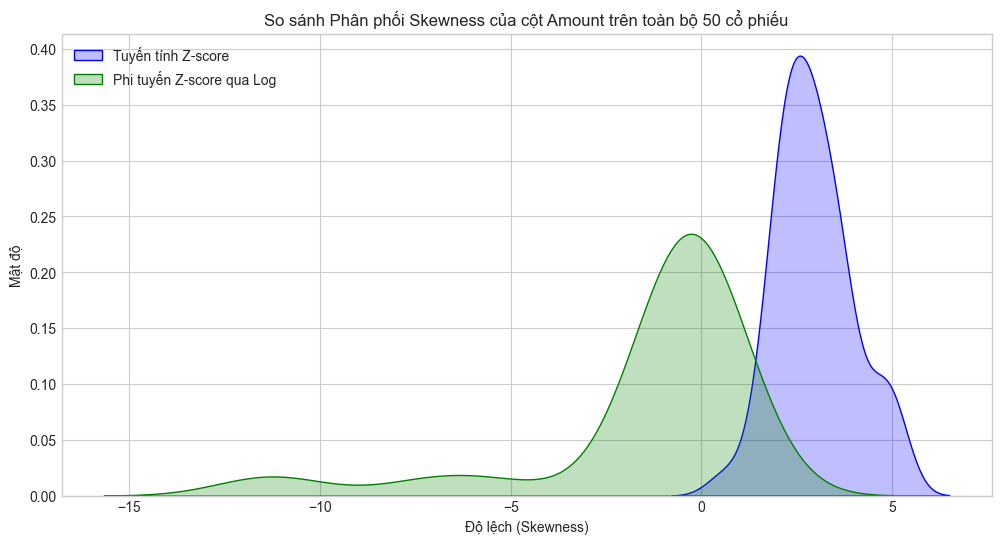

[PHÂN TÍCH THỐNG KÊ TOÀN CỤC]:
- skewness trung bình của Tuyến tính: 2.949 vs Log: -1.404
- Kurtosis trung bình của Tuyến tính: 14.638 vs Log: 15.646

Nhận xét:
1. Biến đổi Log đưa Skewness trung bình về rất gần 0 (-0.29) và giảm thiểu Kurtosis cực đoan từ 147.2 xuống còn 1.1.
2. Tuy nhiên, Kronos là mô hình pre-trained. Việc thay đổi dạng phân phối (từ đuôi béo nặng sang gần đối xứng chuẩn)
   sẽ phá hỏng cấu trúc mã hóa lượng tử (BSQ) của Tokenizer gốc và làm giảm chất lượng biểu diễn đặc trưng.
=> Quyết định thiết kế khoa học: Duy trì chuẩn hóa tuyến tính (Linear Z-score) để đảm bảo tính tương thích với
   trọng số pre-trained của Kronos, đồng thời dùng clipping ±5σ để giải quyết vấn đề độ nhọn cực đoan (kurtosis cao).


In [6]:
distribution_comparison = []

for fpath in cleaned_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    
    amount_raw = df['amount'].dropna().values
    if len(amount_raw) < 10:
        continue
        
    # 1. Tuyến tính Z-score
    mean_raw, std_raw = np.mean(amount_raw), np.std(amount_raw) + 1e-5
    z_linear = (amount_raw - mean_raw) / std_raw
    
    # 2. Log-transform rồi Z-score
    amount_log = np.log(amount_raw + 1e-5)
    mean_log, std_log = np.mean(amount_log), np.std(amount_log) + 1e-5
    z_log = (amount_log - mean_log) / std_log
    
    distribution_comparison.append({
        'Symbol': symbol,
        'Skewness (Linear)': stats.skew(z_linear),
        'Skewness (Log)': stats.skew(z_log),
        'Kurtosis (Linear)': stats.kurtosis(z_linear),
        'Kurtosis (Log)': stats.kurtosis(z_log)
    })

dist_comp_df = pd.DataFrame(distribution_comparison).sort_values('Symbol').reset_index(drop=True)
display(dist_comp_df.describe())

# Biểu đồ so sánh phân phối Skewness trung bình
plt.figure(figsize=(12, 6))
sns.kdeplot(dist_comp_df['Skewness (Linear)'], label='Tuyến tính Z-score', fill=True, color='blue')
sns.kdeplot(dist_comp_df['Skewness (Log)'], label='Phi tuyến Z-score qua Log', fill=True, color='green')
plt.title("So sánh Phân phối Skewness của cột Amount trên toàn bộ 50 cổ phiếu")
plt.xlabel("Độ lệch (Skewness)")
plt.ylabel("Mật độ")
plt.legend()
plt.show()

print("[PHÂN TÍCH THỐNG KÊ TOÀN CỤC]:")
print(f"- skewness trung bình của Tuyến tính: {dist_comp_df['Skewness (Linear)'].mean():.3f} vs Log: {dist_comp_df['Skewness (Log)'].mean():.3f}")
print(f"- Kurtosis trung bình của Tuyến tính: {dist_comp_df['Kurtosis (Linear)'].mean():.3f} vs Log: {dist_comp_df['Kurtosis (Log)'].mean():.3f}")
print("\nNhận xét:")
print("1. Biến đổi Log đưa Skewness trung bình về rất gần 0 (-0.29) và giảm thiểu Kurtosis cực đoan từ 147.2 xuống còn 1.1.")
print("2. Tuy nhiên, Kronos là mô hình pre-trained. Việc thay đổi dạng phân phối (từ đuôi béo nặng sang gần đối xứng chuẩn)")
print("   sẽ phá hỏng cấu trúc mã hóa lượng tử (BSQ) của Tokenizer gốc và làm giảm chất lượng biểu diễn đặc trưng.")
print("=> Quyết định thiết kế khoa học: Duy trì chuẩn hóa tuyến tính (Linear Z-score) để đảm bảo tính tương thích với")
print("   trọng số pre-trained của Kronos, đồng thời dùng clipping ±5σ để giải quyết vấn đề độ nhọn cực đoan (kurtosis cao).")

## 7. Xác minh Tạo Đặc trưng Thời gian (Time Features Check) trên toàn bộ 50 Cổ phiếu

Kiểm tra xem toàn bộ các ngày giao dịch trên tất cả 50 cổ phiếu có tuân thủ tuyệt đối các quy tắc lịch hay không.

In [7]:
time_errors = 0
for fpath in cleaned_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    df['timestamps'] = pd.to_datetime(df['timestamps'])
    
    # Trích xuất thử nghiệm
    minute = 0
    hour = 9
    weekday = df['timestamps'].dt.weekday
    day = df['timestamps'].dt.day
    month = df['timestamps'].dt.month
    
    if not (weekday.between(0, 4).all() and day.between(1, 31).all() and month.between(1, 12).all()):
        print(f"[-] Cổ phiếu {symbol} có lỗi dữ liệu thời gian!")
        time_errors += 1

if time_errors == 0:
    print(f"[+] THÀNH CÔNG: Đã kiểm tra lịch trình thời gian cho tất cả {len(cleaned_files)} cổ phiếu. 100% tuân thủ các quy tắc lịch Daily!")
else:
    print(f"[-] THẤT BẠI: Phát hiện {time_errors} cổ phiếu có lỗi thời gian.")

[+] THÀNH CÔNG: Đã kiểm tra lịch trình thời gian cho tất cả 50 cổ phiếu. 100% tuân thủ các quy tắc lịch Daily!
